Quick EDA of the original data

In [1]:
import time
from datetime import datetime, timedelta

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Timestamp (Start)
current_datetime = datetime.now()
formatted_time = current_datetime.strftime("%Y-%m-%d_%H:%M:%S")
print(formatted_time)

start_time = time.time()

2026-01-08_22:11:16


In [4]:
df = pd.read_csv("../data/original/complaints-2025-11-02_04_18.csv")

In [5]:
df.head(5)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,06/07/25,Debt collection,Federal student loan debt,Attempts to collect debt not owed,Debt was result of identity theft,I am writing to formally dispute the reporting...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",TX,75078,NaN,Consent provided,Web,06/07/25,Closed with non-monetary relief,Yes,NaN,13951186
1,06/04/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,I demand immediate attention to serious inaccu...,NaN,"EQUIFAX, INC.",GA,30518,NaN,Consent provided,Web,06/04/25,Closed with non-monetary relief,Yes,NaN,13899433
2,06/03/25,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,The Fair Credit Reporting Act ( 15 U.S. Code 1...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,TX,77545,NaN,Consent provided,Web,06/03/25,Closed with explanation,Yes,NaN,13876006
3,06/05/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,I am filing this complaint to notify you that ...,NaN,"EQUIFAX, INC.",DE,19720,NaN,Consent provided,Web,06/05/25,Closed with explanation,Yes,NaN,13903580
4,06/05/25,Credit card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,On XX/XX/year> I made a hotel reservation at X...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",MO,641XX,Older American,Consent provided,Web,06/05/25,Closed with non-monetary relief,Yes,NaN,13916506


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28071 entries, 0 to 28070
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Date received                 28071 non-null  object 
 1   Product                       28071 non-null  object 
 2   Sub-product                   28071 non-null  object 
 3   Issue                         28071 non-null  object 
 4   Sub-issue                     27382 non-null  object 
 5   Consumer complaint narrative  28071 non-null  object 
 6   Company public response       15165 non-null  object 
 7   Company                       28071 non-null  object 
 8   State                         27982 non-null  object 
 9   ZIP code                      28071 non-null  object 
 10  Tags                          1605 non-null   object 
 11  Consumer consent provided?    28071 non-null  object 
 12  Submitted via                 28071 non-null  object 
 13  D

In [7]:
df.drop(columns=["Consumer disputed?", "Tags"], inplace=True)

In [8]:
df["word_count"] = df["Consumer complaint narrative"].apply(lambda x: len(str(x).split()))
df["word_count"].describe()

count    28071.000000
mean       184.901963
std        205.859049
min          6.000000
25%         68.000000
50%        123.000000
75%        228.000000
max       3390.000000
Name: word_count, dtype: float64

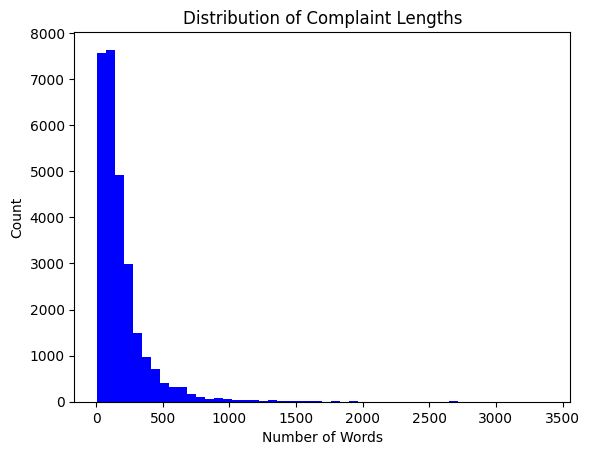

In [9]:
plt.hist(df["word_count"], bins=50, color="blue")
plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.title("Distribution of Complaint Lengths")
plt.show()

In [10]:
df["Product"].value_counts().head(10)

Product
Credit reporting or other personal consumer reports        22603
Debt collection                                             2315
Credit card                                                  843
Checking or savings account                                  834
Money transfer, virtual currency, or money service           407
Mortgage                                                     285
Vehicle loan or lease                                        275
Student loan                                                 237
Payday loan, title loan, personal loan, or advance loan      156
Prepaid card                                                  77
Name: count, dtype: int64

In [11]:
df["Issue"].value_counts().head(10)

Issue
Incorrect information on your report                               10262
Improper use of your report                                         8803
Problem with a company's investigation into an existing problem     3443
Attempts to collect debt not owed                                    922
Written notification about debt                                      686
Managing an account                                                  461
False statements or representation                                   353
Problem with a purchase shown on your statement                      219
Took or threatened to take negative or legal action                  165
Trouble during payment process                                       153
Name: count, dtype: int64

In [12]:
short_texts = df[df["word_count"] < 10]
print(short_texts["Consumer complaint narrative"].value_counts().head(10))

# was going to remove short texts but decided against it as they are mostly all the same complaint and that would skew the data

Consumer complaint narrative
The personal information on my credit report were outdated.                 177
Hard inquiries that is not connected to a account                             3
incorrect personal info and unauthorized inquiries : Address :XX/XX/XXXX      3
Please update my personal information immediately!                            3
There are several fraudulent accounts on my credit report                     3
These accounts are reporting fraudulently, please remove them.                3
Please help me, I have attached supporting documents                          3
Please report correct information on consumer reports.                        3
The amount is incorrect double the amount of XXXX                             3
unauthorized inquiries were added to my credit report                         3
Name: count, dtype: int64


In [13]:
df["Date received"] = pd.to_datetime(df["Date received"])

top_products = df["Product"].value_counts().head(5).index # get the top 5 products
top_issues = df["Issue"].value_counts().head(5).index # top 5 issues

/tmp/ipykernel_66944/3328737037.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date received"] = pd.to_datetime(df["Date received"])


In [14]:
daily_products = df[df["Product"].isin(top_products)].groupby([df["Date received"].dt.day_name(), "Product"]).size().unstack(fill_value=0)
daily_issues = df[df["Issue"].isin(top_issues)].groupby([df["Date received"].dt.day_name(), "Issue"]).size().unstack(fill_value=0)

daily_issues = daily_issues.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
daily_products = daily_products.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])


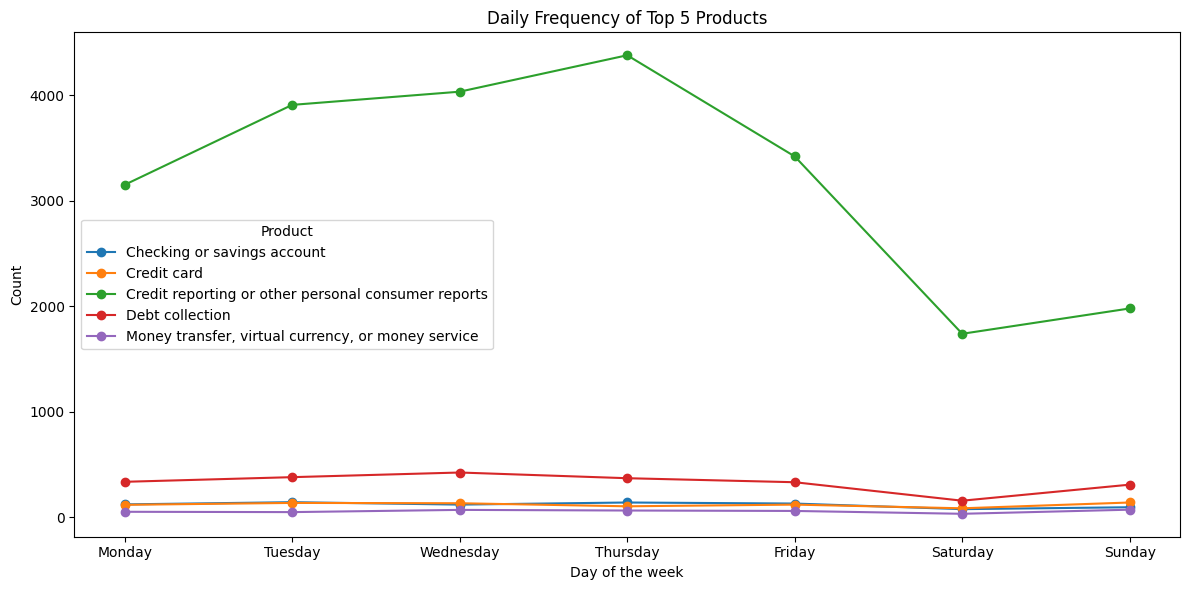

In [15]:
daily_products.plot(figsize=(12,6), marker="o")
plt.title("Daily Frequency of Top 5 Products")
plt.xlabel("Day of the week")
plt.ylabel("Count")
plt.legend(title="Product")
plt.tight_layout()
plt.show()


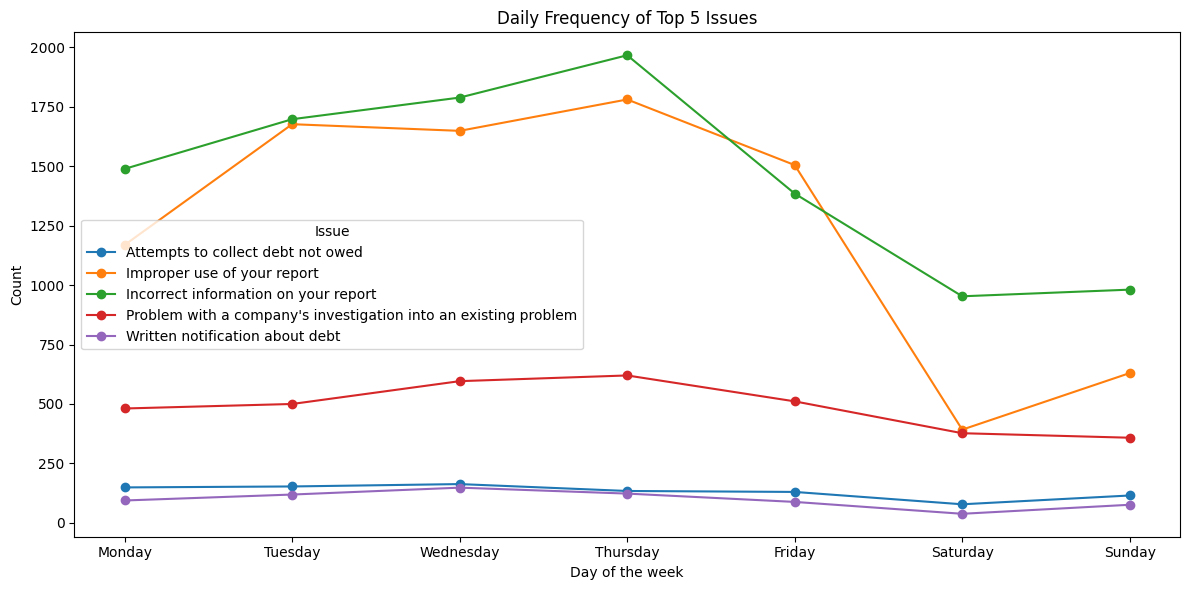

In [16]:
# Plot daily counts for top issues
daily_issues.plot(figsize=(12,6), marker="o")
plt.title("Daily Frequency of Top 5 Issues")
plt.xlabel("Day of the week")
plt.ylabel("Count")
plt.legend(title = "Issue")
plt.tight_layout()
plt.show()

In [17]:
# Timestamp (End)
current_datetime = datetime.now()
formatted_time = current_datetime.strftime("%Y-%m-%d_%H:%M:%S")
print(formatted_time)

end_time = time.time()
elapsed_seconds = end_time - start_time

# Convert elapsed seconds to minutes and seconds
minutes = int(elapsed_seconds // 60)
seconds = elapsed_seconds % 60

print(f"Program elapsed time: {minutes} minutes and {seconds:.2f} seconds")

2026-01-08_22:11:17
Program elapsed time: 0 minutes and 1.04 seconds
